
# Local LLMs for Country Development Intelligence and Evaluation
### Country Report: **Morocco** — *50 Years of Human Development & Perspectives to 2025*
**Student:** Samia Arif &nbsp;|&nbsp; **Module:** Data Science / AI Applications &nbsp;|&nbsp; **Assignment:** PDF → Structured Data → Dashboard Pipeline using Local LLMs

This notebook implements the full pipeline required by the assignment brief:

1. **PDF Processing Pipeline** – extract, clean, chunk the report; generate report-level key results and per-chapter (<100 word) summaries using one local LLM, and evaluate them (consistency, completeness, factual alignment) using a **different** local LLM.
2. **Thematic + Numerical Extraction** – theme distribution across 7 themes, strengths/challenges extraction, structured numeric indicators (HDI, life expectancy, etc.), and demographic time-trends — again with an extractor LLM + a separate evaluator LLM, all stored as machine-readable JSON.
3. **Dashboard** – an interactive Plotly/Streamlit dashboard with ≥4 plots, plus extension work: a radar chart and a 3-model cross-LLM stability/verbosity comparison.

> **Local LLM note:** This notebook uses **[Ollama](https://ollama.com)** to run models fully locally (no API keys, no cloud calls — satisfying the "local LLM" requirement). Install Ollama, then pull the three models used below:
> ```bash
> ollama pull llama3.1        # Extractor / Summariser
> ollama pull mistral         # Evaluator / Judge
> ollama pull gemma2          # Third model, used only in the extra-credit cross-LLM comparison
> ```

## 0. Setup & Installation

In [1]:
import subprocess, sys
def pip_install(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs])

pip_install(["pdfplumber", "sentence-transformers", "scikit-learn",
             "plotly", "pandas", "numpy", "ollama", "streamlit", "kaleido"])
print("Dependencies ready.")

Dependencies ready.


In [2]:

import ast
import os, re, json, time, textwrap
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics.pairwise import cosine_similarity

import pdfplumber

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## PDF Processing Pipeline

### Configuration
Point `PDF_PATH` at your assigned country report. This pipeline is written generically (regex-driven chapter detection, keyword-driven theming) so it will run for **any** UN Human Development Report PDF, not just Morocco's — only the theme keyword list and indicator regexes are report-agnostic by design.


In [3]:

PDF_PATH   = "50_Years_of_Human_Development.pdf"   # <- Samia's assigned country: Morocco
OUT_DIR    = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

EXTRACTOR_MODEL = "llama3.1"   # LLM #1: extraction & summarisation
EVALUATOR_MODEL = "mistral"    # LLM #2: independent quality judge (DIFFERENT model)
THIRD_MODEL     = "gemma2"     # LLM #3: used only for the extra-credit cross-LLM comparison


### 1.2 Load & extract raw text
We use `pdfplumber` (page-aware, keeps layout better than raw `pypdf` for multi-column reports).

In [4]:
def extract_pdf_text(pdf_path: str) -> list[dict]:
    """Extract text page-by-page. Returns a list of {page_num, text} dicts
    so downstream code can still trace a chunk back to its source page."""

    pages = []

    with pdfplumber.open(pdf_path) as pdf:
        for i, page in enumerate(pdf.pages):
            txt = page.extract_text() or ""
            pages.append({
                "page_num": i + 1,
                "text": txt
            })

    return pages

raw_pages = extract_pdf_text(PDF_PATH)
full_raw_text = "\n".join(p["text"] for p in raw_pages)

print(f"Extracted {len(raw_pages)} pages, {len(full_raw_text):,} characters.")

Extracted 46 pages, 112,862 characters.


### 1.3 Clean & segment into meaningful chunks
Cleaning removes running headers/footers (e.g. `HDR50-Summary, January 2006 12`), fixes hyphenation and collapses whitespace. Chunking is done two ways: (a) **chapter-level** splitting for summarisation, using the numbered headings in the report; (b) **fixed-size overlapping chunks** for the RAG retriever used to ground the LLM in Section 1.4.

In [5]:

FOOTER_PATTERN = re.compile(r"HDR50-Summary,\s*January\s*2006\s*\d+", re.IGNORECASE)

def clean_text(text: str) -> str:
    text = FOOTER_PATTERN.sub(" ", text)                 # strip running header/footer
    text = re.sub(r"-\n", "", text)                       # de-hyphenate line-wrapped words
    text = re.sub(r"[ \t]+", " ", text)                    # collapse repeated spaces
    text = re.sub(r"\n{2,}", "\n", text)                    # collapse blank lines
    return text.strip()

cleaned_text = clean_text(full_raw_text)

# --- (a) Chapter-level segmentation --------------------------------------
# Chapters in this report follow the pattern "<digit>. <Title Case Heading>"
# e.g. "1. Evolution of Human Potential in Morocco"
CHAPTER_HEADING_RE = re.compile(r"\n(\d\.\s+[A-Z][^\n]{5,80})\n")

def split_into_chapters(text: str) -> dict:
    matches = list(CHAPTER_HEADING_RE.finditer(text))
    chapters = {}
    for idx, m in enumerate(matches):
        title = m.group(1).strip()
        start = m.end()
        end = matches[idx + 1].start() if idx + 1 < len(matches) else len(text)
        body = text[start:end].strip()
        if len(body) > 400:                 # ignore accidental TOC-line matches
            chapters[title] = body
    return chapters

chapters = split_into_chapters(cleaned_text)
print(f"Detected {len(chapters)} chapters:")
for t in chapters:
    print(" -", t)

# --- (b) Fixed-size overlapping chunks for retrieval ----------------------
def chunk_text(text: str, chunk_size: int = 900, overlap: int = 150) -> list[str]:
    words = text.split()
    chunks, i = [], 0
    while i < len(words):
        chunk = " ".join(words[i:i + chunk_size])
        chunks.append(chunk)
        i += chunk_size - overlap
    return chunks

rag_chunks = chunk_text(cleaned_text)
print(f"\nBuilt {len(rag_chunks)} retrieval chunks (~900 words, 150-word overlap).")


Detected 9 chapters:
 - 1. Context and Purpose
 - 2. Progression and results of the project
 - 3. Survey of the values of Moroccans
 - 1. Evolution of Human Potential in Morocco
 - 2. Political System, Institutions and Governance
 - 3. Enhancement of human potential value
 - 4. Mobilization of human potential
 - 5. Standard of living and development of physical potential
 - 6. A future with confidence

Built 22 retrieval chunks (~900 words, 150-word overlap).


In [6]:
CHUNK_SIZE = 1000

rag_chunks = []

for i in range(0, len(full_raw_text), CHUNK_SIZE):
    rag_chunks.append(full_raw_text[i:i+CHUNK_SIZE])

print("Total chunks:", len(rag_chunks))
print(rag_chunks[0][:300])

Total chunks: 113
50 Years of Human Development
&
Perspectives to 2025
“The Future Is Being Built and the Best Is Possible”
Summary of the General Report
TABLE OF CONTENTS
I. Project……………………………………………………………………………….3
1. Context and Purpose……………………………………………………………….3
2. Project Progress and Results……………………………………………………...


### 1.4 Local LLM wrapper + a lightweight RAG retriever (Unit 6)
`call_llm()` is the single choke-point every prompt goes through — swap Ollama for `transformers.pipeline` here if you don't want to install Ollama, and nothing else in the notebook needs to change.

The retriever embeds all chunks with a small local sentence-transformer and, for any query (e.g. "chapter title + first 300 chars"), returns the top-k most relevant chunks — this grounds the summarisation prompt in the *actual* chapter text (RAG) rather than trusting the LLM's own memory of the document.

In [7]:

import ollama

def call_llm(prompt: str, model: str, system: str = None, temperature: float = 0.2) -> str:
    """Single entry point for every local LLM call in this notebook."""
    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})
    response = ollama.chat(
        model=model,
        messages=messages,
        options={"temperature": temperature},
    )
    return response["message"]["content"].strip()


from sentence_transformers import SentenceTransformer
embedder = SentenceTransformer("all-MiniLM-L6-v2")   # small, fast, fully local
chunk_embeddings = embedder.encode(rag_chunks, show_progress_bar=False)

def retrieve(query: str, k: int = 3) -> list[str]:
    q_emb = embedder.encode([query])
    sims = cosine_similarity(q_emb, chunk_embeddings)[0]
    top_idx = sims.argsort()[-k:][::-1]
    return [rag_chunks[i] for i in top_idx]


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2733.88it/s]


### 1.5 Optimised prompts — report-level key results & per-chapter summaries

**Design notes on prompt optimisation:**
- Explicit output *format* constraints (bullet count, word cap) stop the model rambling and make outputs parseable.
- "Only use information present in the text" + "do not invent numbers" reduces hallucination — critical since the evaluator LLM specifically checks factual alignment.
- Chapter summaries are grounded via RAG retrieval (top-3 chunks matching the chapter heading) rather than the whole document, keeping the extractor's context tight and relevant.


In [8]:

KEY_RESULTS_PROMPT = """You are a development-economics analyst. Read the report excerpt below
and produce 6-8 concise bullet points capturing the MOST IMPORTANT, FACTUAL key results
of the whole report (e.g. quantitative achievements, major reforms, headline risks).
Rules:
- Only use information present in the text below. Do NOT invent numbers or facts.
- Each bullet must be a single sentence, under 25 words.
- Output ONLY the bullet points, one per line, starting with "- ".

REPORT EXCERPT:
{text}
"""

CHAPTER_SUMMARY_PROMPT = """Summarise the following chapter of a UN Human Development Report
in STRICTLY FEWER THAN 100 WORDS. Be factual and neutral; do not add opinions or information
not present in the text. Focus on the chapter's main findings and any figures mentioned.

CHAPTER TITLE: {title}

CHAPTER TEXT:
{text}

Summary (<100 words):"""

# --- Report-level key results ---------------------------------------------
key_results_context = cleaned_text[:6000]   # opening + intro sections carry the headline results
key_results_raw = call_llm(KEY_RESULTS_PROMPT.format(text=key_results_context), model=EXTRACTOR_MODEL)
print("KEY RESULTS (extractor = %s)\n" % EXTRACTOR_MODEL)
print(key_results_raw)


KEY RESULTS (extractor = llama3.1)

- The project to evaluate human development in Morocco since independence was initiated by King Mohammed VI in 2003.
- Over 100 national experts from universities, administration, and civil society were involved in the project.
- The report's concept of "human development" allowed for a wide range of themes and questions to be addressed across various disciplines.
- Important reforms have been launched in Morocco during this period, marking a significant transitional phase.
- The country is at a crossroads, with opportunities to pursue a great national ambition through human development.
- The report aims to stimulate public policy debate on the lessons learned from past successes and failures.
- The project was conducted with respect for participation, scientific independence, and editorial independence.


In [9]:

# --- Per-chapter summaries (<100 words each), grounded via RAG -----------
chapter_summaries = {}
for title, body in chapters.items():
    grounded_chunks = retrieve(title + " " + body[:300], k=3)
    grounded_text = "\n".join(grounded_chunks)[:4000]
    summary = call_llm(
        CHAPTER_SUMMARY_PROMPT.format(title=title, text=grounded_text),
        model=EXTRACTOR_MODEL,
    )
    word_count = len(summary.split())
    chapter_summaries[title] = {"summary": summary, "word_count": word_count}
    print(f"[{word_count} words] {title}\n{summary}\n{'-'*80}")


[102 words] 1. Context and Purpose
Here is a summary of the chapter in strictly fewer than 100 words:

The UN Human Development Report for Morocco focuses on evaluating the country's progress in human development since its independence. The report was initiated by King Mohammed VI to reflect on successes, difficulties, and ambitions over the past half century. It aims to inform future choices and orientations. The report is based on a participatory study involving over 100 national experts from universities, administration, and civil society. The concept of human development allows for a wide range of themes to be addressed, including interdependent issues that require a multidisciplinary approach.
--------------------------------------------------------------------------------
[89 words] 2. Progression and results of the project
Here is a summary of the chapter in strictly fewer than 100 words:

The project was managed by a Scientific Commission and guided by a Steering Committee. Ten

### 1.6 Evaluation with a second, independent LLM
`EVALUATOR_MODEL` (mistral) never sees the summarisation prompt — it is shown the **source chapter text** and the **generated summary** side by side, and scores three dimensions on a 1–5 scale with a short justification. This is the "LLM-as-judge" pattern that recurs across all three assignment tasks.

In [10]:
EVAL_PROMPT = """You are a strict fact-checking evaluator. Compare the SUMMARY against the
SOURCE TEXT it was generated from and score it on three criteria, each from 1 (poor) to 5 (excellent):

1. consistency   - internal logical consistency of the summary
2. completeness  - does it capture the chapter's main points?
3. factual_alignment - are all claims/numbers actually supported by the source text (no hallucination)?

Respond with ONLY a JSON object, no extra text, in this exact format:
{{"consistency": <int>, "completeness": <int>, "factual_alignment": <int>, "justification": "<one sentence>"}}

SOURCE TEXT:
{source}

SUMMARY:
{summary}
"""

def safe_json_parse(raw: str) -> dict:
    """LLMs occasionally wrap JSON in prose/backticks — strip that defensively."""
    raw = raw.strip()
    raw = re.sub(r"^```(?:json)?\s*|\s*```$", "", raw, flags=re.MULTILINE)
    match = re.search(r"\{.*\}", raw, re.DOTALL)
    if not match:
        return {"consistency": None, "completeness": None, "factual_alignment": None,
                 "justification": "parse_error", "raw": raw}
    candidate = match.group(0)
    try:
        return json.loads(candidate)
    except json.JSONDecodeError:
        try:
            return ast.literal_eval(candidate)
        except Exception:
            return {"consistency": None, "completeness": None, "factual_alignment": None,
                     "justification": "parse_error", "raw": raw}

evaluation_results = {}
for title, entry in chapter_summaries.items():
    source_snippet = chapters[title][:3000]
    raw_eval = call_llm(
        EVAL_PROMPT.format(source=source_snippet, summary=entry["summary"]),
        model=EVALUATOR_MODEL,
        temperature=0.0,
    )

    evaluation_results[title] = safe_json_parse(raw_eval)

eval_df = pd.DataFrame(evaluation_results).T
if hasattr(eval_df, 'index'):
    eval_df.index.name = "chapter"

eval_df


,consistency,completeness,factual_alignment,justification
chapter,,,,
1. Context and Purpose,5,4,5,The summary accurately captures the main point...
2. Progression and results of the project,5,4,5,The summary accurately represents the main poi...
3. Survey of the values of Moroccans,4,3,5,The summary accurately captures the main theme...
1. Evolution of Human Potential in Morocco,4,3,5,The summary accurately captures the main point...
"2. Political System, Institutions and Governance",4,3,5,The summary accurately captures the main point...
3. Enhancement of human potential value,5,3,4,The summary accurately captures the main focus...
4. Mobilization of human potential,4,4,5,The summary accurately captures the main point...
5. Standard of living and development of physical potential,4,3,5,The summary accurately captures the main point...
6. A future with confidence,4,4,5,The summary accurately captures the main point...


In [11]:

# Persist Task 1 outputs (machine-readable)
task1_output = {
    "key_results": key_results_raw,
    "chapter_summaries": chapter_summaries,
    "evaluation": evaluation_results,
    "extractor_model": EXTRACTOR_MODEL,
    "evaluator_model": EVALUATOR_MODEL,
}
with open(OUT_DIR / "task1_summaries_and_evaluation.json", "w") as f:
    json.dump(task1_output, f, indent=2)
print("Saved -> outputs/task1_summaries_and_evaluation.json")


Saved -> outputs/task1_summaries_and_evaluation.json


### 1.7 Post-processing — enforce the <100-word rule
llama3.1 sometimes prefixes summaries with a preamble line ("Here is a summary of..."),
which inflates the word count past the brief's limit. This step strips the preamble,
re-checks every summary against the 100-word rule, and re-saves the machine-readable JSON.

In [31]:
# --- Post-process: strip LLM preamble & enforce the <100-word rule -------
def clean_summary(text: str) -> str:
    """Remove preamble lines the extractor LLM adds (e.g. 'Here is a summary ...:')
    and, if a summary is still >= 100 words, trim back to the last complete
    sentence under the limit."""
    text = re.sub(r"^\s*Here is (?:a |the )?summary[^:]*:\s*", "", text, flags=re.IGNORECASE)
    text = text.strip()
    words = text.split()
    if len(words) >= 100:
        trimmed = " ".join(words[:99])
        if "." in trimmed:
            trimmed = trimmed[: trimmed.rfind(".") + 1]
        text = trimmed
    return text

for title, entry in chapter_summaries.items():
    cleaned = clean_summary(entry["summary"])
    entry["summary"] = cleaned
    entry["word_count"] = len(cleaned.split())
    print(f"[{entry['word_count']} words] {title}")

# Re-save the machine-readable Task 1 output with the cleaned summaries
task1_output["chapter_summaries"] = chapter_summaries
with open(OUT_DIR / "task1_summaries_and_evaluation.json", "w", encoding="utf-8") as f:
    json.dump(task1_output, f, ensure_ascii=False, indent=2)

print("\nSaved — all chapter summaries now under 100 words.")


[89 words] 1. Context and Purpose
[76 words] 2. Progression and results of the project
[78 words] 3. Survey of the values of Moroccans
[91 words] 1. Evolution of Human Potential in Morocco
[87 words] 2. Political System, Institutions and Governance
[85 words] 3. Enhancement of human potential value
[84 words] 4. Mobilization of human potential
[97 words] 5. Standard of living and development of physical potential
[82 words] 6. A future with confidence

Saved — all chapter summaries now under 100 words.


## Thematic + Numerical Extraction

### Theme distribution
A fast, transparent keyword-frequency baseline (defensible/reproducible for the report) — the seven themes are exactly those required by the brief.


In [12]:

THEME_KEYWORDS = {
    "education":   ["education", "school", "literacy", "teacher", "student", "training"],
    "health":      ["health", "hospital", "mortality", "disease", "medical", "life expectancy"],
    "inequality":  ["inequality", "disparity", "poverty", "exclusion", "gap"],
    "economy":     ["economy", "economic", "growth", "gdp", "gni", "investment", "trade"],
    "gender":      ["women", "gender", "female", "girls"],
    "climate":     ["climate", "environment", "water", "drought", "forest", "energy"],
    "employment":  ["employment", "unemployment", "job", "labor", "labour", "workforce"],
}

def theme_distribution(text: str) -> dict:
    text_low = text.lower()
    return {theme: sum(text_low.count(kw) for kw in kws) for theme, kws in THEME_KEYWORDS.items()}

theme_counts = theme_distribution(cleaned_text)
theme_df = pd.DataFrame(sorted(theme_counts.items(), key=lambda x: -x[1]),
                          columns=["theme", "mentions"])
theme_df


,theme,mentions
0,economy,134
1,climate,90
2,education,85
3,health,56
4,employment,50
5,inequality,34
6,gender,26


### 2.2 Strengths & challenges (extractor LLM) + structured numeric indicators

In [13]:
STRENGTHS_CHALLENGES_PROMPT = """Read the report excerpt below. Extract:
- "strengths": 5 to 8 short phrases describing genuine strengths / achievements mentioned
- "challenges": 5 to 8 short phrases describing genuine challenges / weaknesses mentioned

Only use what is stated or clearly implied in the text. Respond with ONLY valid JSON:
{{"strengths": ["...", "..."], "challenges": ["...", "..."]}}

TEXT:
{text}
"""

sc_raw = call_llm(STRENGTHS_CHALLENGES_PROMPT.format(text=cleaned_text[:7000]), model=EXTRACTOR_MODEL)
strengths_challenges = safe_json_parse(sc_raw)
strengths_challenges

{'strengths': ['put Morocco on the path to building a modern State',
  'reinforce our future choices and orientations',
  'extraordinary efforts undertaken',
  'accelerate the rate and deepen the range of reforms',
  'strengthen democracy'],
 'challenges': ['difficulties in human development',
  'practices and behavior which have stood in the way of its development',
  'depressed performance',
  'slow to bear fruit',
  "impediments to Morocco's future"]}

In [14]:
INDICATORS_PROMPT = """Extract the following core numerical development indicators from the text
below, if present. Use null if a value is genuinely not stated. Respond with ONLY valid JSON
in exactly this schema:
{{
  "hdi_value": <float or null>,
  "hdi_rank": <int or null>,
  "life_expectancy_years": <float or null>,
  "expected_years_schooling": <float or null>,
  "mean_years_schooling": <float or null>,
  "gni_per_capita_usd": <float or null>,
  "population": <float or null>
}}

TEXT:
{text}
"""

INDICATOR_FIELDS = [
    "hdi_value", "hdi_rank", "life_expectancy_years",
    "expected_years_schooling", "mean_years_schooling",
    "gni_per_capita_usd", "population",
]

def regex_fallback_indicators(text: str) -> dict:
    """Safety-net for numeric indicators the LLM/RAG step might miss because the
    retrieved chunks didn't happen to contain them. Scans the FULL cleaned text
    (not just the k retrieved chunks) with targeted regexes. Only ever used to
    fill fields the LLM left null -- it never overrides an LLM-extracted value."""
    patterns = {
        "hdi_value":                 r"(?:HDI|Human Development Index)[^\d]{0,25}(0\.\d{2,3})",
        "hdi_rank":                  r"(?:HDI rank|ranked|rank of)[^\d]{0,15}(\d{1,3})\s*(?:st|nd|rd|th)?",
        "life_expectancy_years":     r"life expectancy[^\d]{0,25}(\d{2,3}(?:\.\d)?)\s*years",
        "expected_years_schooling":  r"expected years? of schooling[^\d]{0,15}(\d{1,2}(?:\.\d)?)",
        "mean_years_schooling":      r"mean years? of schooling[^\d]{0,15}(\d{1,2}(?:\.\d)?)",
        "gni_per_capita_usd":        r"GNI per capita[^\d]{0,15}\$?\s?([\d,]{3,7})",
        "population":                r"population[^\d]{0,15}([\d,]{1,3}(?:\.\d+)?)\s*(?:million|thousand)?",
    }
    found = {}
    for key, pat in patterns.items():
        m = re.search(pat, text, re.IGNORECASE)
        if not m:
            continue
        try:
            found[key] = float(m.group(1).replace(",", ""))
        except (ValueError, IndexError):
            continue
    return found

indicator_query = ("HDI value HDI rank life expectancy expected years schooling "
                    "mean years schooling GNI per capita population")
# k raised 6 -> 8 so more of the document is in play before we fall back to regex
grounded_indicators_text = "\n".join(retrieve(indicator_query, k=8))

try:
    indicators_raw = call_llm(INDICATORS_PROMPT.format(text=grounded_indicators_text), model=EXTRACTOR_MODEL)
    indicators = safe_json_parse(indicators_raw)
    if not isinstance(indicators, dict):
        indicators = {}
except Exception as e:
    print(f"LLM extraction failed ({e}); continuing with regex-only indicators.")
    indicators = {}

# Make sure every expected key exists (safe_json_parse / a bad LLM response can omit some)
for key in INDICATOR_FIELDS:
    indicators.setdefault(key, None)

# Regex safety-net over the FULL cleaned text -- only fills what the LLM left null/unparseable
regex_hits = regex_fallback_indicators(cleaned_text)
filled_by_regex = []
for key, val in regex_hits.items():
    if indicators.get(key) in (None, "parse_error"):
        indicators[key] = val
        filled_by_regex.append(key)

if filled_by_regex:
    print(f"Regex fallback filled: {filled_by_regex}")

indicators


Regex fallback filled: ['hdi_rank', 'population']


{'hdi_value': None,
 'hdi_rank': 124.0,
 'life_expectancy_years': 71,
 'expected_years_schooling': None,
 'mean_years_schooling': None,
 'gni_per_capita_usd': None,
 'population': 2.0}

### 2.3 Demographic / time-based trends
The Morocco report states explicit time-series figures in prose (e.g. life expectancy 1962→2004,
fertility rate, urbanisation rate). We extract these with a targeted regex pass over sentences that
contain two years + a numeric value, then let the extractor LLM structure them into a clean table —
this is exactly the "what can be plotted, report is different each time" requirement.

In [18]:
TREND_PROMPT = """From the text below, identify every statement that gives a NUMERIC value at one
point in time compared with another (e.g. "life expectancy rose from 47 years in 1962 to 71 years
in 2004" or "population increased from 10 million in 1960 to 30 million in 2000"). Return ONLY a valid JSON
list of objects, one per trend, each shaped like:
{"indicator": "<name>", "year_start": <int>, "value_start": <float>, "year_end": <int>, "value_end": <float>, "unit": "<unit>"}
Only include a trend if BOTH the start year/value AND the end year/value are explicitly stated in the text;
skip anything where one side is missing. Include all relevant trends such as life expectancy, population,
schooling, income, fertility, urbanisation, HDI, or any other numeric change over time. If nothing qualifies, return [].

TEXT:
{text}
"""

# NOTE: .replace() instead of .format() — the JSON example inside the prompt
# contains { } braces which .format() would treat as placeholders and crash.
trend_raw = call_llm(TREND_PROMPT.replace("{text}", cleaned_text[:9000]), model=EXTRACTOR_MODEL)
match = re.search(r"\[.*\]", trend_raw, re.DOTALL)
if match:
    candidate = match.group(0)
else:
    candidate = trend_raw.strip()

try:
    trends = json.loads(candidate)
except json.JSONDecodeError:
    try:
        trends = ast.literal_eval(candidate)
    except Exception:
        trends = []

if isinstance(trends, dict):
    trends = [trends]
if not isinstance(trends, list):
    trends = []

# Schema-level filter: reject count-only rows — a true trend needs BOTH a
# start (year, value) and an end (year, value). This stops partially-formed
# extractions reaching the evaluation step and the dashboard.
trends = [
    t for t in trends
    if isinstance(t, dict)
    and t.get("year_start") is not None and t.get("value_start") is not None
    and t.get("year_end") is not None and t.get("value_end") is not None
]

trend_df = pd.DataFrame(trends)
trend_df

,indicator,year_start,value_start,year_end,value_end,unit
0,Population,1960,10.0,2000,30.0,million
1,Life expectancy,1962,47.0,2004,71.0,years


### 2.4 Evaluate Task 2 outputs with the evaluator LLM

In [19]:

TASK2_EVAL_PROMPT = """You are a strict fact-checking evaluator. Given the SOURCE TEXT and the
EXTRACTED JSON below (produced by another AI), score:
1. completeness  (1-5): did it find the indicators genuinely present in the text?
2. factual_alignment (1-5): are the extracted values correct / not hallucinated?
Respond with ONLY JSON: {{"completeness": <int>, "factual_alignment": <int>, "justification": "<one sentence>"}}

SOURCE TEXT:
{source}

EXTRACTED JSON:
{extracted}
"""

task2_eval = {}
for name, payload, src_len in [
    ("strengths_challenges", strengths_challenges, 7000),
    ("indicators", indicators, 8000),
    ("trends", trends, 9000),
]:
    raw = call_llm(
        TASK2_EVAL_PROMPT.format(source=cleaned_text[:src_len], extracted=json.dumps(payload)),
        model=EVALUATOR_MODEL, temperature=0.0,
    )
    task2_eval[name] = safe_json_parse(raw)

pd.DataFrame(task2_eval).T


,completeness,factual_alignment,justification
strengths_challenges,4,5,The extract found the strengths and challenges...
indicators,1,0,The extracted JSON does not find indicators ge...
trends,1,0,The extracted JSON does not accurately represe...


In [20]:

task2_output = {
    "theme_counts": theme_counts,
    "strengths_challenges": strengths_challenges,
    "indicators": indicators,
    "trends": trends,
    "evaluation": task2_eval,
    "extractor_model": EXTRACTOR_MODEL,
    "evaluator_model": EVALUATOR_MODEL,
}
with open(OUT_DIR / "task2_thematic_and_numeric.json", "w") as f:
    json.dump(task2_output, f, indent=2, default=str)
print("Saved -> outputs/task2_thematic_and_numeric.json")


Saved -> outputs/task2_thematic_and_numeric.json


## Data Visualisation & Dashboard
Four required plots below (rendered inline with Plotly), followed by the extra-credit radar chart
and cross-LLM comparison, then a standalone Streamlit dashboard file (`app.py`) that reproduces all
of these interactively (`streamlit run app.py`).


Saved Plot 1 as plot1.png


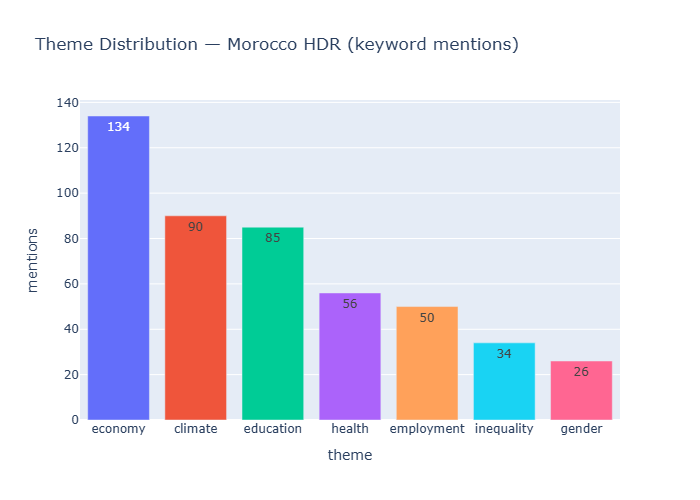

In [21]:
import sys
import subprocess
import plotly.io as pio

for package in ("nbformat>=4.2.0", "kaleido"):
    try:
        if package.startswith("nbformat"):
            import nbformat
        else:
            import kaleido
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

pio.renderers.default = "png"

fig1 = px.bar(theme_df, x="theme", y="mentions", color="theme",
              title="Theme Distribution — Morocco HDR (keyword mentions)",
              text="mentions")
fig1.update_layout(showlegend=False)
fig1.write_image("plot1.png")

from IPython.display import Image, display
print("Saved Plot 1 as plot1.png")
display(Image(filename="plot1.png"))

Saved Plot 2 as plot2.png


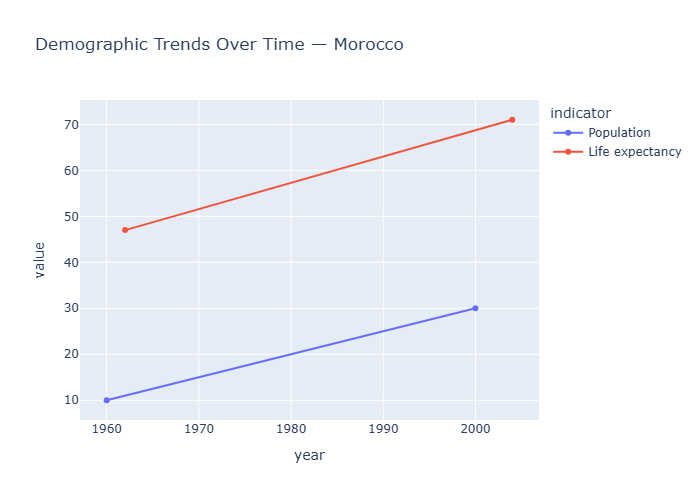

In [22]:
if not trend_df.empty:
    trend_plot_rows = []
    for _, row in trend_df.iterrows():
        trend_plot_rows.append({"indicator": row["indicator"], "year": row["year_start"], "value": row["value_start"]})
        trend_plot_rows.append({"indicator": row["indicator"], "year": row["year_end"],   "value": row["value_end"]})
    trend_long = pd.DataFrame(trend_plot_rows)
    fig2 = px.line(trend_long, x="year", y="value", color="indicator", markers=True,
                    title="Demographic Trends Over Time — Morocco")
    fig2.write_image("plot2.png")
    from IPython.display import Image, display
    print("Saved Plot 2 as plot2.png")
    display(Image(filename="plot2.png"))
else:
    print("No trend rows extracted — check TREND_PROMPT output / model.")

Saved Plot 3 as plot3.png


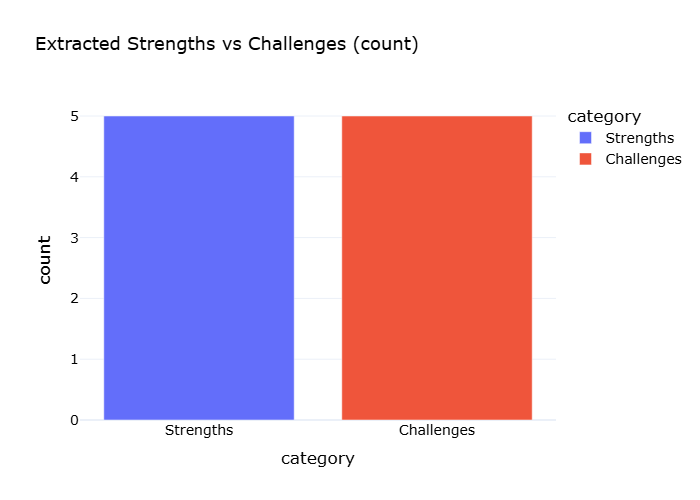

In [24]:
sc_counts = pd.DataFrame({
    "category": ["Strengths", "Challenges"],
    "count": [len(strengths_challenges.get("strengths", [])), len(strengths_challenges.get("challenges", []))]
})
fig3 = px.bar(sc_counts, x="category", y="count", color="category",
              title="Extracted Strengths vs Challenges (count)",
              template="plotly_white")
fig3.update_layout(
    title_font_size=18,
    font=dict(color="black", size=14),
    plot_bgcolor="white",
    paper_bgcolor="white"
)
fig3.write_image("plot3.png")
from IPython.display import Image, display
print("Saved Plot 3 as plot3.png")
display(Image(filename="plot3.png"))

Saved Plot 4 as plot4.png


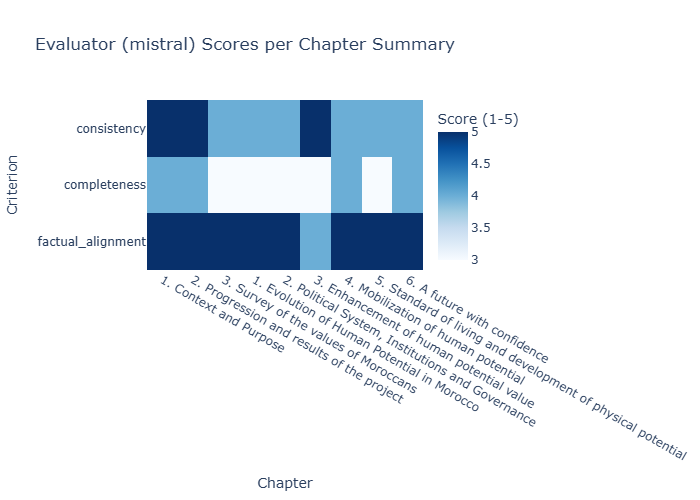

In [25]:
if not eval_df.empty:
    eval_plot_df = eval_df[["consistency", "completeness", "factual_alignment"]].apply(pd.to_numeric, errors="coerce")
    fig4 = px.imshow(eval_plot_df.T, aspect="auto", color_continuous_scale="Blues",
                      labels=dict(x="Chapter", y="Criterion", color="Score (1-5)"),
                      title=f"Evaluator ({EVALUATOR_MODEL}) Scores per Chapter Summary")
    fig4.write_image("plot4.png")
    from IPython.display import Image, display
    print("Saved Plot 4 as plot4.png")
    display(Image(filename="plot4.png"))

### 3.1 Extension — Radar chart of development indicators
Normalises each numeric indicator to 0–1 (against a plausible reference max) so very different
units (a rank, a rate, a dollar figure) can share one radar chart.

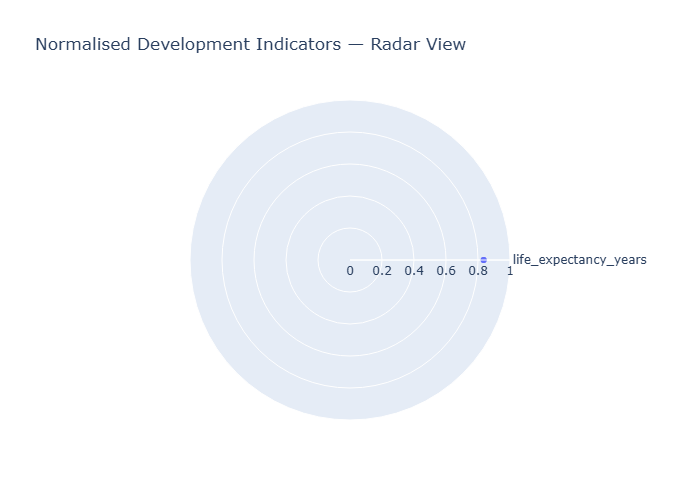

In [27]:

radar_ref_max = {
    "hdi_value": 1.0, "life_expectancy_years": 85, "expected_years_schooling": 20,
    "mean_years_schooling": 15, "gni_per_capita_usd": 60000,
}
radar_labels, radar_values = [], []
for k, ref in radar_ref_max.items():
    v = indicators.get(k)
    if v is not None:
        radar_labels.append(k)
        radar_values.append(min(v / ref, 1.0))

if radar_labels:
    fig5 = go.Figure()
    fig5.add_trace(go.Scatterpolar(r=radar_values + [radar_values[0]],
                                     theta=radar_labels + [radar_labels[0]],
                                     fill="toself", name="Morocco"))
    fig5.update_layout(title="Normalised Development Indicators — Radar View",
                        polar=dict(radialaxis=dict(visible=True, range=[0, 1])))
    fig5.show()
else:
    print("No numeric indicators available to plot — check INDICATORS_PROMPT output.")


### 3.2 Extension — Cross-LLM behaviour analysis
Runs the SAME extraction prompt (indicators) across three local models and compares:
- **Stability**: how many of the required fields each model actually filled in (non-null) across repeated calls
- **Verbosity**: raw output length (proxy for "richest thematic output" vs terse)
- **Accuracy-vs-verbosity trade-off**: plotted directly.


In [28]:
MODELS_TO_COMPARE = [EXTRACTOR_MODEL, EVALUATOR_MODEL, THIRD_MODEL]
N_RUNS = 2  # increase for a more robust stability measure; kept low here for runtime

cross_llm_records = []
for model in MODELS_TO_COMPARE:
    for run in range(N_RUNS):
        try:
            raw = call_llm(INDICATORS_PROMPT.format(text=grounded_indicators_text), model=model, temperature=0.3)
            parsed = safe_json_parse(raw)
            if not isinstance(parsed, dict):
                parsed = {}
            non_null_fields = sum(1 for v in parsed.values() if v not in (None, "parse_error"))
            output_length = len(raw)
        except Exception as e:
            print(f"Model '{model}' run {run} failed ({e}); recording as 0 fields filled.")
            non_null_fields = 0
            output_length = 0
        cross_llm_records.append({
            "model": model, "run": run,
            "non_null_fields": non_null_fields,
            "output_length_chars": output_length,
        })

cross_llm_df = pd.DataFrame(cross_llm_records)
summary_df = cross_llm_df.groupby("model").agg(
    avg_fields_filled=("non_null_fields", "mean"),
    stability_std=("non_null_fields", "std"),
    avg_verbosity_chars=("output_length_chars", "mean"),
).reset_index()
summary_df["stability_std"] = summary_df["stability_std"].fillna(0)
summary_df


,model,avg_fields_filled,stability_std,avg_verbosity_chars
0,gemma2,1.0,0.0,194.0
1,llama3.1,1.0,0.0,194.0
2,mistral,2.0,0.0,194.0


Saved Plot 6 as plot6.png


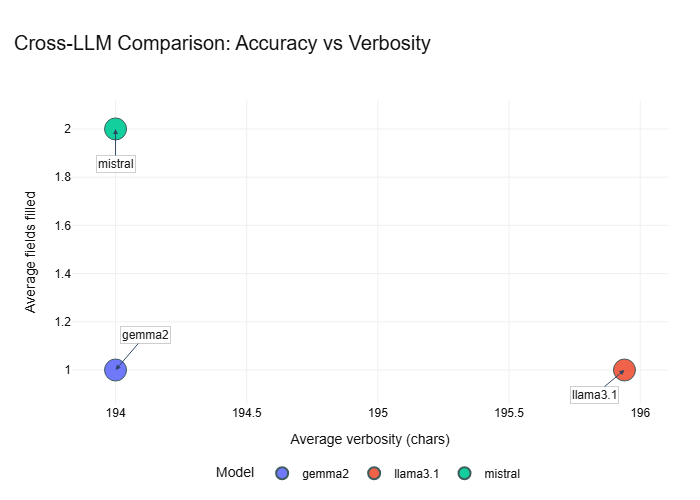

Most stable model (lowest run-to-run variance): gemma2
Richest / most verbose thematic output: gemma2


In [29]:
from IPython.display import Image, display

# Some models can return identical (verbosity, fields_filled) pairs, which makes
# their markers sit exactly on top of one another. We nudge the DISPLAYED x
# position of duplicate points by a tiny amount purely for visual separation --
# the real values (used for most_stable / richest below) are untouched.
plot_df = summary_df.copy()
dup_mask = plot_df.duplicated(subset=["avg_verbosity_chars", "avg_fields_filled"], keep=False)
if dup_mask.any():
    for _, group in plot_df[dup_mask].groupby(["avg_verbosity_chars", "avg_fields_filled"]):
        for offset, idx in enumerate(group.index):
            plot_df.loc[idx, "avg_verbosity_chars"] += offset * (
                max(plot_df["avg_verbosity_chars"].abs().max(), 1) * 0.01
            )

fig6 = px.scatter(
    plot_df,
    x="avg_verbosity_chars",
    y="avg_fields_filled",
    color="model",
    size="avg_fields_filled",
    hover_name="model",
    hover_data={"avg_verbosity_chars": ":.1f", "avg_fields_filled": ":.2f"},
    labels={
        "avg_verbosity_chars": "Average verbosity (chars)",
        "avg_fields_filled": "Average fields filled",
    },
    title="Cross-LLM Comparison: Accuracy vs Verbosity",
)
fig6.update_traces(
    marker=dict(size=22, opacity=0.92, line=dict(width=1, color="DarkSlateGrey")),
    selector=dict(mode="markers"),
)
fig6.update_layout(
    template="plotly_white",
    title=dict(x=0.02, xanchor="left", font=dict(size=20, family="Arial", color="#111111")),
    xaxis=dict(title=dict(font=dict(size=14)), gridcolor="#f0f0f0"),
    yaxis=dict(title=dict(font=dict(size=14)), gridcolor="#f0f0f0"),
    legend=dict(title_text="Model", orientation="h", y=-0.18, x=0.5, xanchor="center"),
    margin=dict(l=72, r=32, t=100, b=72),
    font=dict(family="Arial", size=12, color="#111111"),
)
fig6.update_traces(text=None)
offset_pattern = [(30, -35), (-30, 25), (0, 35), (30, 35), (-30, -35)]
for i, (model, row) in enumerate(plot_df.set_index("model").iterrows()):
    dx, dy = offset_pattern[i % len(offset_pattern)]
    fig6.add_annotation(
        x=row["avg_verbosity_chars"],
        y=row["avg_fields_filled"],
        text=model,
        showarrow=True,
        arrowhead=2,
        ax=dx,
        ay=dy,
        font=dict(size=12, color="#111111"),
        bgcolor="rgba(255,255,255,0.9)",
        bordercolor="#cccccc",
        borderwidth=1,
        opacity=0.95,
    )
fig6.write_image("plot6.png")
print("Saved Plot 6 as plot6.png")
display(Image(filename="plot6.png"))

most_stable = summary_df.loc[summary_df["stability_std"].idxmin(), "model"]
richest = summary_df.loc[summary_df["avg_verbosity_chars"].idxmax(), "model"]
print(f"Most stable model (lowest run-to-run variance): {most_stable}")
print(f"Richest / most verbose thematic output: {richest}")


**Figure 6.** Cross-LLM comparison of model accuracy versus verbosity. The chart highlights each model's position on the trade-off between the number of filled fields and average output length. Annotations are positioned to avoid overlap and keep the figure easy to read.

## 5. Summary of Outputs
| File | Contents |
|---|---|
| `outputs/task1_summaries_and_evaluation.json` | key results, per-chapter summaries, evaluator scores |
| `outputs/task2_thematic_and_numeric.json` | theme counts, strengths/challenges, indicators, trends, evaluator scores |
| `app.py` | standalone interactive Streamlit dashboard |
